In [2]:
#import statements
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
from tqdm import tqdm
import heyoka as hy
from scipy import signal
import sympy as sp
import time

from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

In [3]:
#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

In [4]:
########################### TEST PARTICLE CASE ###################################3

sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e5,int(1e5))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:17<00:00, 5779.91it/s]

Energy percent change:  1.28e-12 %
Final MEGNO value:  2.99e+01


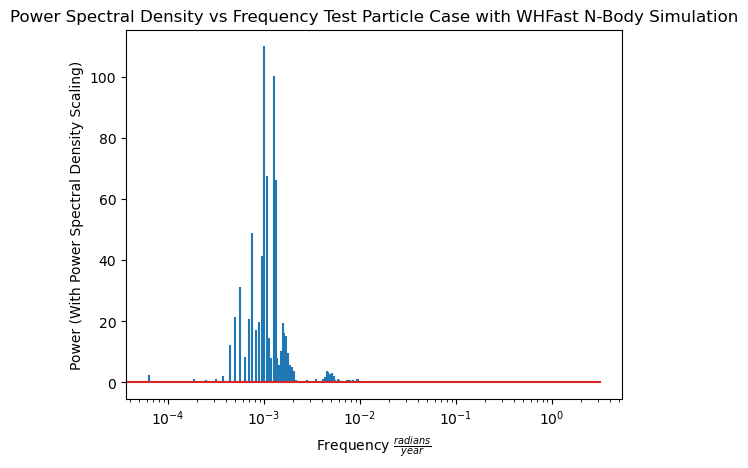

In [5]:
#fourier transform
f,pxx = pomega_ft(times, long_peri_sat_test_n_body, e_sat_test_n_body)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with WHFast N-Body Simulation')
plt.show()

In [6]:
############### MASSIVE CASE #########################################
sim_full_n_body = rebound.Simulation()
sim_full_n_body.add(m=1, hash = "Sun")
sim_full_n_body.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_full_n_body.add(m=m_sat,a=8.87,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_full_n_body.move_to_com()

sat = sim_full_n_body.particles[2]
jup = sim_full_n_body.particles[1]

times = np.linspace(0,1e5,int(1e5))*2*np.pi
long_peri_sat_full_n_body = np.zeros(len(times))
e_sat_full_n_body = np.zeros(len(times))
a_sat_full_n_body = np.zeros(len(times))
p_sat_full_n_body = np.zeros(len(times))

long_peri_j_full_n_body = np.zeros(len(times))
e_j_full_n_body = np.zeros(len(times))
a_j_full_n_body = np.zeros(len(times))
p_j_full_n_body = np.zeros(len(times))

sim_full_n_body.init_megno()
e_i_full_n_body = sim_full_n_body.energy()

for i in tqdm(range(len(times))):
    sim_full_n_body.integrate(times[i])
    
    long_peri_sat_full_n_body[i] = sat.pomega
    e_sat_full_n_body[i] = sat.e
    a_sat_full_n_body[i] = sat.a
    p_sat_full_n_body[i] = sat.P

    long_peri_j_full_n_body[i] = jup.pomega
    e_j_full_n_body[i] = jup.e
    a_j_full_n_body[i] = jup.a
    p_j_full_n_body[i] = jup.P

e_f = sim_full_n_body.energy()
m_f = sim_full_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:15<00:00, 6268.39it/s]

Energy percent change:  1.82e+01 %
Final MEGNO value:  4.01e+01


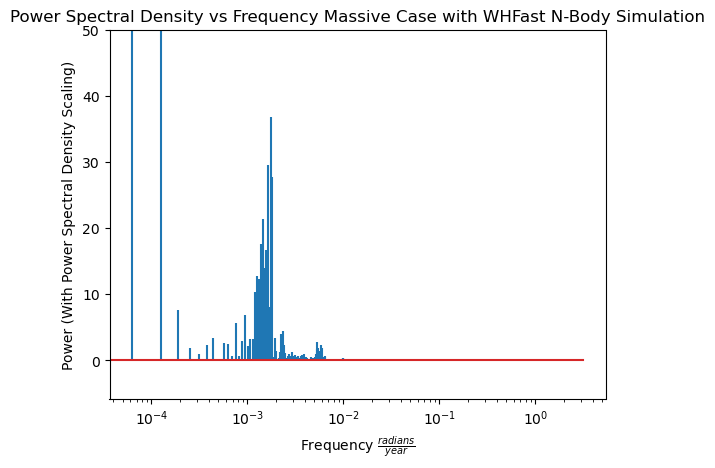

In [7]:
#fourier transform
f,pxx = pomega_ft(times, long_peri_sat_full_n_body, e_sat_full_n_body)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Massive Case with WHFast N-Body Simulation')
plt.ylim(top=50)
plt.show()

## Celmech

In [8]:
############## FIRST ORDER MMR ################################

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham_1st_ord_MMR = PoincareHamiltonian(pvars)
pham_1st_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_1st_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1) 



times, pomega_sat_1st_ord_MMR, pomega_j_1st_ord_MMR, e_sat_1st_ord_MMR, a_sat_1st_ord_MMR, a_jup_1st_ord_MMR, lam_sat,lam_jup = hk_integrate(pham_1st_ord_MMR, 1e5, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634826521e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:06<00:00, 14563.71it/s]

-8.880166634826649e-05
Energy Percent Change: 1.4345874408192958e-12 %
*** Simulation Complete ***
Time elapsed  = 6.870250040999963 seconds


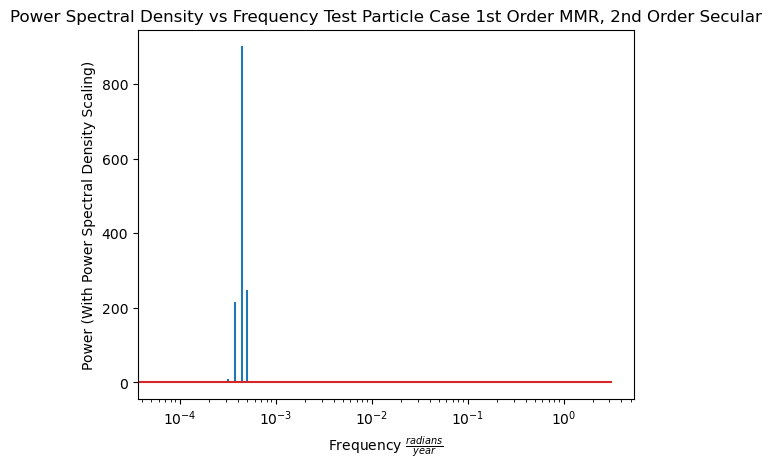

In [9]:
#fourier transform
f,pxx = pomega_ft(times, pomega_sat_1st_ord_MMR, e_sat_1st_ord_MMR)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case 1st Order MMR, 2nd Order Secular')
plt.show()

In [10]:
#################### SECOND ORDER MMR ###########################
pham_2dn_ord_MMR = PoincareHamiltonian(pvars)
pham_2dn_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_2dn_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat_2dn_ord_MMR, pomega_j_2dn_ord_MMR, e_sat_2dn_ord_MMR, a_sat_2dn_ord_MMR, a_jup_2dn_ord_MMR, lam_sat,lam_jup = hk_integrate(pham_2dn_ord_MMR, 1e5, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663483416e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:07<00:00, 14002.42it/s]

-8.88016663483354e-05
Energy Percent Change: 6.974536813338875e-12 %
*** Simulation Complete ***
Time elapsed  = 7.146556932000749 seconds


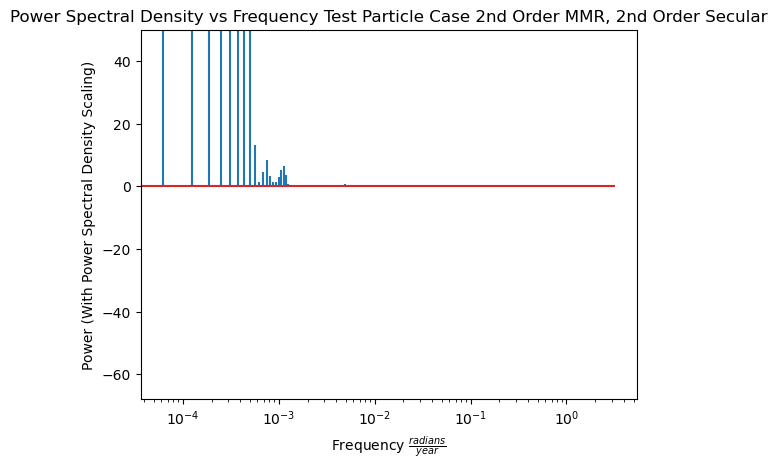

In [16]:
#fourier transform
f,pxx = pomega_ft(times, pomega_sat_2dn_ord_MMR, e_sat_2dn_ord_MMR)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylim(top = 50)
plt.show()

In [21]:
##################### THIRD ORDER MMR ####################################
pham_3rd_ord_MMR = PoincareHamiltonian(pvars)
pham_3rd_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_3rd_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3) 

times, pomega_sat_3rd_ord_MMR, pomega_j_3rd_ord_MMR, e_sat_3rd_ord_MMR, a_sat_3rd_ord_MMR, a_jup_3rd_ord_MMR, sat_lam, jup_lam = hk_integrate(pham_3rd_ord_MMR, 1e5, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634834955e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:09<00:00, 10155.01it/s]

-8.88016663483442e-05
Energy Percent Change: 6.028319565139188e-12 %
*** Simulation Complete ***
Time elapsed  = 9.850979756000015 seconds


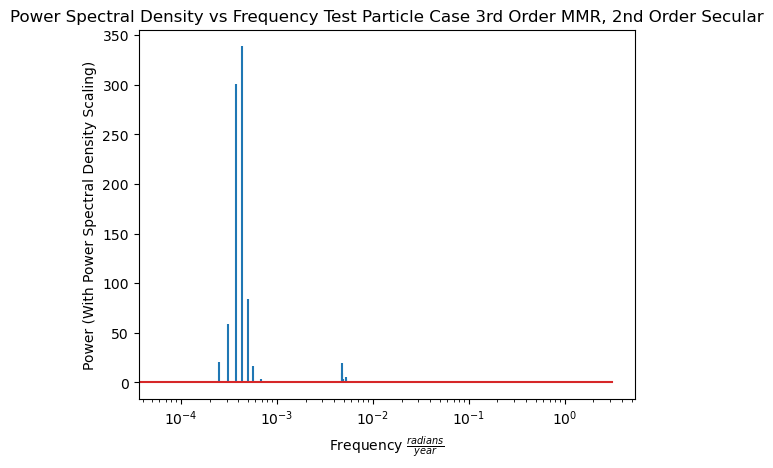

In [22]:
#fourier transform
f,pxx = pomega_ft(times, pomega_sat_3rd_ord_MMR, e_sat_3rd_ord_MMR)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case 3rd Order MMR, 2nd Order Secular')
plt.show()

In [14]:
########################### FOURTH ORDER MMR ##############################
pham_4th_ord_MMR = PoincareHamiltonian(pvars)
pham_4th_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_4th_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4) 

times, pomega_sat_4th_ord_MMR, pomega_j_4th_ord_MMR, e_sat_4th_ord_MMR, a_sat_4th_ord_MMR, a_jup_4th_ord_MMR, lam_sat, lam_j = hk_integrate(pham_4th_ord_MMR, 1e5, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663483499e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:13<00:00, 7420.79it/s]

-8.880166634834821e-05
Energy Percent Change: 1.907696064917457e-12 %
*** Simulation Complete ***
Time elapsed  = 13.479124555999078 seconds


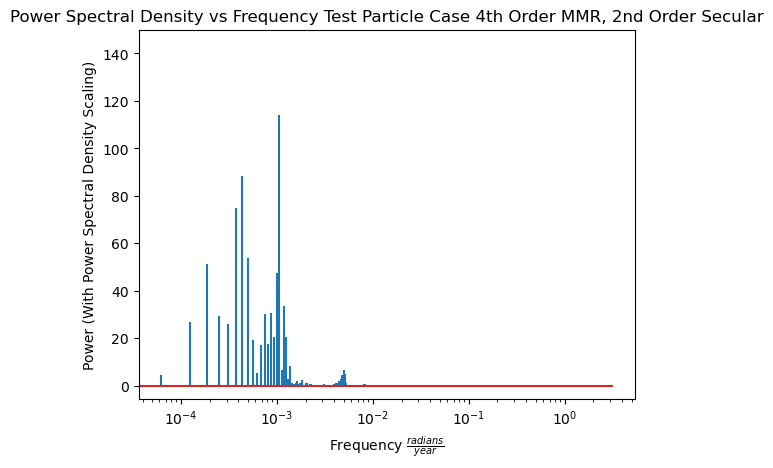

In [15]:
#fourier transform
f,pxx = pomega_ft(times, pomega_sat_4th_ord_MMR, e_sat_4th_ord_MMR)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case 4th Order MMR, 2nd Order Secular')
plt.ylim(top=150)
plt.show()